In [1]:
using Pkg
Pkg.activate("/global/homes/j/jgmorawe/emulators_pipeline")

  Activating project at `~/emulators_pipeline`


In [2]:
using Effort
using AbstractCosmologicalEmulators
using PyCall
using Plots
using NPZ
using DelimitedFiles
using DataInterpolations

In [3]:
# Loads the different emulator components (monopole, quadrupole, hexadecapole)
home_dir = "/global/homes/j/jgmorawe/emulators_pipeline"
FS_emu_mono = Effort.load_multipole_emulator(home_dir * "/trained_effort_velocileptors_rept_mnuw0wacdm_50000/0/")
FS_emu_quad = Effort.load_multipole_emulator(home_dir * "/trained_effort_velocileptors_rept_mnuw0wacdm_50000/2/")
FS_emu_hexa = Effort.load_multipole_emulator(home_dir * "/trained_effort_velocileptors_rept_mnuw0wacdm_50000/4/")

PℓEmulator(ComponentEmulator(LuxEmulator(Lux.Chain{@NamedTuple{layer_1::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_3::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_4::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_5::Lux.Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothing}((layer_1 = Dense(9 => 32, tanh), layer_2 = Dense(32 => 32, tanh), layer_3 = Dense(32 => 32, tanh), layer_4 = Dense(32 => 32, tanh), layer_5 = Dense(32 => 165)), nothing), (layer_1 = (weight = Float32[0.12866618 0.06616345 … -0.15187398 -0.10081121; 0.0049915174 -0.074732184 … -0.508055 -0.21988599; … ; -0.18027411 0.051960334 … -0.41924295 -0.23864757; 0.08730349 -0.026820734 … -0.43762022 -0.055745557], bias = Float32[-0.16850919, 0.5436207, 0.12790033, 0.30755758, 0.1170085, 0.6245116, -0.12678763, 0.48402265, -1.0324254

In [4]:
# Function to calculate theory vector
function theory_FS(effort_cosmo, eft_params_eulerian, z, D, kin)
    """Computes the stacked monopole/quadrupole/hexadecapole (with AP applied) given cosmological and EFT parameters."""
    emulator_input = [z, effort_cosmo.ln10Aₛ, effort_cosmo.nₛ, effort_cosmo.h*100, effort_cosmo.ωb, effort_cosmo.ωc,
                      effort_cosmo.mν, effort_cosmo.w0, effort_cosmo.wa]
    q_par, q_perp = Effort.q_par_perp(z, effort_cosmo, effort_cosmo_fid)
    pk0 = Effort.get_Pℓ(emulator_input, D, eft_params_eulerian, FS_emu_mono)
    pk2 = Effort.get_Pℓ(emulator_input, D, eft_params_eulerian, FS_emu_quad)
    pk4 = Effort.get_Pℓ(emulator_input, D, eft_params_eulerian, FS_emu_hexa)
    pk0_AP, pk2_AP, pk4_AP = Effort.apply_AP(vec(FS_emu_mono.P11.kgrid), kin, pk0, pk2, pk4, q_par, q_perp, n_GL_points=8)
    return vcat(pk0_AP, pk2_AP, pk4_AP)
end

# The 'output' theory vector which DESI uses (different from the emulator grid)
desi_kin = readdlm("/global/homes/j/jgmorawe/emulators_pipeline/desi_kin.txt")

349×1 Matrix{Float64}:
 0.001
 0.002
 0.003
 0.004
 0.005
 0.006
 0.007
 0.008
 0.009000000000000001
 0.010000000000000002
 0.011
 0.012
 0.013000000000000001
 ⋮
 0.338
 0.339
 0.34
 0.341
 0.342
 0.343
 0.34400000000000003
 0.34500000000000003
 0.34600000000000003
 0.34700000000000003
 0.34800000000000003
 0.34900000000000003

In [5]:
# Uses a test set of cosmological and EFT parameters
z, ln10As, ns, H0, ombh2, omch2, Mnu, w0, wa = 0.5, 2.8, 1.02, 59, 0.0235, 0.15, 0.06, -0.7, -0.9
emulator_input = [z, ln10As, ns, H0, ombh2, omch2, Mnu, w0, wa]
eft_params_eulerian = [1, -0.2, 0.5, 0.3, 15, -50, -25, 30, 0, 0, 0] # b1, b2, bs, b3, alpha0, alpha2, alpha4, alpha6, st0, st2, st4

# Initiates the effort cosmology for it, as well as the fiducial model (for purposes of computing AP later)
effort_cosmo = Effort.w0waCDMCosmology(ln10Aₛ=ln10As, nₛ=ns, h=H0/100, ωb=ombh2, ωc=omch2, mν=Mnu, w0=w0, wa=wa, ωk=0)
effort_cosmo_fid = Effort.w0waCDMCosmology(ln10Aₛ=3.044, nₛ=0.9649, h=0.6736, ωb=0.02237, ωc=0.12, mν=0.06, w0=-1, wa=0, ωk=0)

# Computes linear growth factor 
D = Effort.D_z(z, effort_cosmo)

# Computes the raw emulator prediction (without AP)
P0_emu_noAP = Effort.get_Pℓ(emulator_input, D, eft_params_eulerian, FS_emu_mono)
P2_emu_noAP = Effort.get_Pℓ(emulator_input, D, eft_params_eulerian, FS_emu_quad)
P4_emu_noAP = Effort.get_Pℓ(emulator_input, D, eft_params_eulerian, FS_emu_hexa)
k_emu = vec(FS_emu_mono.P11.kgrid)

55-element Vector{Float64}:
 0.0005
 0.001
 0.0013894954943731374
 0.0019306977288832496
 0.0026826957952797246
 0.003727593720314938
 0.005179474679231213
 0.0071968567300115215
 0.01
 0.013160740129524926
 0.017320508075688777
 0.02279507056954777
 0.029
 ⋮
 0.2840000000000001
 0.3
 0.316
 0.332
 0.34800000000000003
 0.36400000000000005
 0.38000000000000006
 0.4
 0.42500000000000004
 0.45000000000000007
 0.4750000000000001
 0.5000000000000001

In [6]:
# Function to apply AP (in Python)
PyCall.py"""def q_par_perp(z, cosmo, cosmo_ref):
    q_par = (cosmo_ref.Hubble(z)/cosmo_ref.Hubble(0))/(cosmo.Hubble(z)/cosmo.Hubble(0))
    q_perp = (cosmo.angular_distance(z)*cosmo.Hubble(0))/(cosmo_ref.angular_distance(z)*cosmo_ref.Hubble(0))
    return [q_par, q_perp]
"""

In [7]:
# Compare with the exact velocileptor prediction
classy = pyimport("classy")
EPT = pyimport("velocileptors_free.EPT.ept_fullresum_fftw")
UTILS = pyimport("velocileptors_free.Utils.pnw_dst")
np = pyimport("numpy")

konhmin = 1e-4
konhmax = 10
nk = 20000
konh = np.logspace(np.log10(konhmin), np.log10(konhmax), nk)
kv_target = k_emu
CosmoDict = Dict("z" => z, "ln10As" => ln10As, "ns" => ns, "H0" => H0, "omega_b" => ombh2, "omega_cdm" => omch2, "Mnu" => Mnu, "w0" => w0, "wa" => wa)
z = CosmoDict["z"]
cosmo_params = Dict("output" => "mPk", "P_k_max_h/Mpc" => 20.0, "z_pk" => "0.0,3.", "h" => CosmoDict["H0"] / 100, "omega_b" => CosmoDict["omega_b"],
                    "omega_cdm" => CosmoDict["omega_cdm"], "ln10^{10}A_s" => CosmoDict["ln10As"], "n_s" => CosmoDict["ns"], "tau_reio" => 0.0568,
                    "N_ur" => 2.0308, "N_ncdm" => 1, "m_ncdm" => CosmoDict["Mnu"], "use_ppf" => "yes", "w0_fld" => CosmoDict["w0"], "wa_fld" => CosmoDict["wa"],
                    "fluid_equation_of_state" => "CLP", "cs2_fld" => 1.0, "Omega_Lambda" => 0.0, "Omega_scf" => 0.0)
cosmo = classy.Class()
cosmo.set(cosmo_params)
cosmo.compute()
f = cosmo.scale_independent_growth_factor_f(z)
plin = [cosmo.pk_cb(k * CosmoDict["H0"] / 100, z) * (CosmoDict["H0"] / 100)^3 for k in konh]
knw, Pnw = UTILS.pnw_dst(konh, plin)
PT = EPT.REPT(knw, plin, pnw=Pnw, kvec=kv_target, beyond_gauss=true, one_loop=true, N=2000, 
              extrap_min=-6, extrap_max=2, cutoff=100, threads=1)
b = eft_params_eulerian
kv, P0, P2, P4 = PT.compute_redshift_space_power_multipoles(b, f, apar=1.0, aperp=1.0, ngauss=4)

# Computes prediction again but this time with AP incorporated
PT = EPT.REPT(knw, plin, pnw=Pnw, kvec=kv_target, beyond_gauss=true, one_loop=true, N=2000, 
              extrap_min=-6, extrap_max=2, cutoff=100, threads=1)
qpar, qperp = q_par_perp(z, effort_cosmo, effort_cosmo_fid)
kv_AP, P0_AP, P2_AP, P4_AP = PT.compute_redshift_space_power_multipoles(b, f, apar=qpar, aperp=qperp, ngauss=4)

/global/homes/j/jgmorawe/.conda/envs/classy_env/lib/python3.10/site-packages/velocileptors_free/Utils/loginterp.py:37: RuntimeWarning: invalid value encountered in divide
  lneff, rneff = deriv(np.log(x[lp]))/y[lp], deriv(np.log(x[rp]))/y[rp]


([0.0005, 0.001, 0.0013894954943731374, 0.0019306977288832496, 0.0026826957952797246, 0.003727593720314938, 0.005179474679231213, 0.0071968567300115215, 0.01, 0.013160740129524926  …  0.316, 0.332, 0.34800000000000003, 0.36400000000000005, 0.38000000000000006, 0.4, 0.42500000000000004, 0.45000000000000007, 0.4750000000000001, 0.5000000000000001], [930.5981847046578, 1715.9010162020295, 2320.8836195947924, 3140.865356380856, 4229.626342324439, 5634.279281860081, 7374.083486404079, 9403.313295506312, 11553.831503978507, 13187.05607623538  …  1048.4536630953896, 997.4355939530582, 953.5983414118549, 913.633638174301, 876.0570375929618, 833.2965212759821, 790.4863812617775, 759.2321238463825, 738.0714588427047, 725.5525924520149], [732.9784854383283, 1472.92592930684, 2041.8524259253518, 2811.0119530926113, 3828.5978184046717, 5134.328370425968, 6738.134047755902, 8582.89190313807, 10487.45773944542, 11859.745625022935  …  -946.8173923807572, -970.0664400967273, -994.7788174370203, -1018.6

In [8]:
# Computes the emulator prediction with AP incorporated too
result_emu_AP = theory_FS(effort_cosmo, eft_params_eulerian, z, D, kv_target)

165-element Vector{Float64}:
   927.7184617340288
  1701.0407524105262
  2299.705238060641
  3125.8159673949385
  4231.232658949711
  5643.656241433068
  7379.308585165042
  9398.2634338023
 11539.818119795693
 13166.006919019062
 14292.212786692324
 14501.451796344003
 13661.248042609539
     ⋮
   597.9559728879957
   615.2714048486844
   629.9509621744596
   642.0170022157731
   653.8926799530992
   662.6950692774938
   668.7208676498187
   675.9081991110709
   687.0371890043164
   694.7895354636463
   696.3425796255109
   690.7785834685972

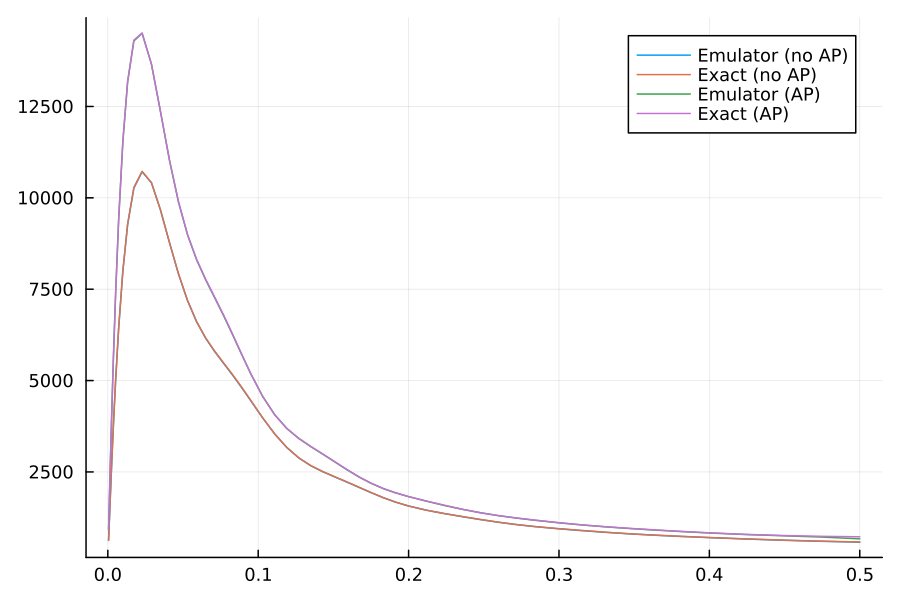

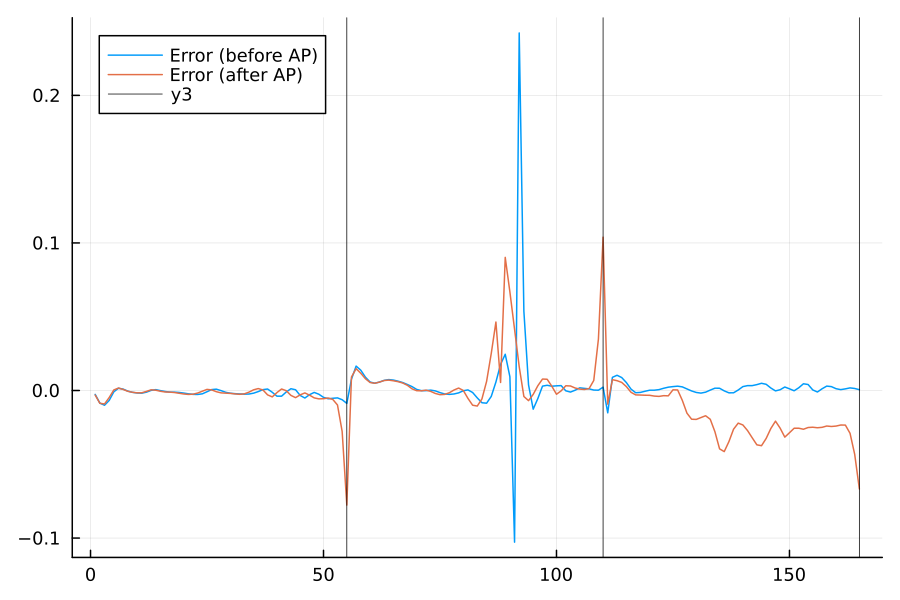

In [9]:
# Displays the various results

exact_noAP = vcat(P0, P2, P4)
emu_noAP = vcat(P0_emu_noAP, P2_emu_noAP, P4_emu_noAP)
exact_AP = vcat(P0_AP, P2_AP, P4_AP)
emu_AP = result_emu_AP

# Plots the monopole only for all four scenarios
p1 = plot(k_emu, emu_noAP[1:55], label="Emulator (no AP)", dpi=150)
plot!(k_emu, exact_noAP[1:55], label="Exact (no AP)")
plot!(k_emu, emu_AP[1:55], label="Emulator (AP)")
plot!(k_emu, exact_AP[1:55], label="Exact (AP)")

# Plots the relative percentage error 
p2 = plot((emu_noAP .- exact_noAP) ./ exact_noAP, label="Error (before AP)", dpi=150)
plot!((emu_AP .- exact_AP) ./ exact_AP, label="Error (after AP)")
vline!([55, 55*2, 55*3], color=:black, lw=0.5)

display(p1)
display(p2)